<a href="https://colab.research.google.com/github/ChenHY1217/Projects-In-MLAI/blob/main/ProjectsinMLAIhw4_task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task1 - Modern Character-Level Language Modeling

### Record environment

In [ ]:
!nvidia-smi

Thu Mar  5 19:54:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P0             46W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# check library versions
import torch
import numpy as np
print(f"PyTorch Version: {torch.__version__}")
print(f"NumPy Version: {np.__version__}")

# fix random seeds
seed = 1337
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)

PyTorch Version: 2.10.0+cu128
NumPy Version: 2.0.2


### Clone Repo

link: https://github.com/karpathy/**nanoGPT**

In [ ]:
# clone
!git clone https://github.com/karpathy/nanoGPT
%cd nanoGPT

# Prepare the Tiny Shakespeare dataset
!python data/shakespeare_char/prepare.py

Cloning into 'nanoGPT'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 975.24 KiB | 42.40 MiB/s, done.
Resolving deltas: 100% (382/382), done.
/content/nanoGPT/nanoGPT/nanoGPT
length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens


## Part A - Train a small GPT

Since this training would be step-based, we need to map the checkpoints.

steps_per_epoch = floor(num_train_tokens /
(batch_size × block_size))

And since train has 1003854 tokens, a batch_size of 64 and a block_size of 256, we have that the steps_per_epoch is 61.

So 5 epochs is about 305 steps, 50 is 3050 steps, and 500 is 30500 steps.

In [ ]:
!python train.py config/train_shakespeare_char.py --max_iters=305 --eval_interval=305 --dtype=float16 --compile=True
# Backup the checkpoint
!cp out-shakespeare-char/ckpt.pt out-shakespeare-char/ckpt_5epochs.pt

Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger because number of 

In [ ]:
!python train.py config/train_shakespeare_char.py --init_from='resume' --max_iters=3050 --eval_interval=3050 --dtype=float16 --compile=True
# Backup the checkpoint
!cp out-shakespeare-char/ckpt.pt out-shakespeare-char/ckpt_50epochs.pt

Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger because number of 

In [ ]:
!python train.py config/train_shakespeare_char.py --init_from='resume' --max_iters=30500 --eval_interval=30500 --dtype=float16 --compile=True
# Backup the checkpoint
!cp out-shakespeare-char/ckpt.pt out-shakespeare-char/ckpt_500epochs.pt

Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger because number of 

### Generate Samples

Prompt: default ("\n")

Sample from 5 epochs (305 steps)

In [ ]:
# Copy the 5-epoch checkpoint to the default name
!cp out-shakespeare-char/ckpt_5epochs.pt out-shakespeare-char/ckpt.pt

# Sample from 5 epochs
!python sample.py --out_dir=out-shakespeare-char --num_samples=1 --max_new_tokens=800

Overriding: out_dir = out-shakespeare-char
Overriding: num_samples = 1
Overriding: max_new_tokens = 800
number of parameters: 10.65M
Loading meta from data/shakespeare_char/meta.pkl...

What thy bridce?

SORTHUSSS:
How is thy be to take On the dagaid
My arthing tules the that dilsh aness.

HENRY BONE:
You her hear them of is he comms heling,
We misee sen commeatient drove the deave the his trace!

ANNE:
And my like wouch have up the speaw yet love she rooke slaves
And the shall make on in on her evich own the crrive ceessire sto-shall his butes and thrught!
I have you must with all of which Pried my of that our hastion is a and beaces and thiu him to mare.

CRIUS:
Who, my care king to skeem such of I what that
That his good not bet same madand the mance
To the with owen it scous some shout might. 
IELLOUCESTER:
Hese shall the he move Ladidiass
Let ou so me by soiever umpous of fear tal not com lovesce!

HERMIONENRYIZETH:
Molk to way! beake baglaw thus with soul him self m
-------------

Sample from 50 epochs (3050 steps)

In [ ]:
# Copy the 5-epoch checkpoint to the default name
!cp out-shakespeare-char/ckpt_50epochs.pt out-shakespeare-char/ckpt.pt

# Sample from 50 epochs
!python sample.py --out_dir=out-shakespeare-char --num_samples=1 --max_new_tokens=800

Overriding: out_dir = out-shakespeare-char
Overriding: num_samples = 1
Overriding: max_new_tokens = 800
number of parameters: 10.65M
Loading meta from data/shakespeare_char/meta.pkl...


ANGELO:
And come, come away towards Barnet with him.

Servant:

Provost:
If some occasion direction swear play,
To appear on the hopeful innocent life,
But, at little born pilgrimage; or then, in the man
Are jocundly and tears the recorder of the people,
Which shall know their vantage.

DUKE VINCENTIO:
Now, by their heads them,
With whom it hath often he touch'd him not.

ANGELO:
If thou do repent to the devilish place,
Which being better ward than thou constain the realm.

ISABELLA:
And for that my lady's brother was the woman;
Howe'er the noble teeth that hath sent to me the wall;
I, who, in the manner of my breast,
Who thou wouldst be put before the duke with my shore,
Sith the state and traitor, as I think it must be,
You sleep as enemies.

CAMILLO:
My lord,
I build the gods for my li
-------------

Sample from 500 epochs (30500 steps)

In [ ]:
# Copy the 5-epoch checkpoint to the default name
!cp out-shakespeare-char/ckpt_500epochs.pt out-shakespeare-char/ckpt.pt

# Sample from 500 epochs
!python sample.py --out_dir=out-shakespeare-char --num_samples=1 --max_new_tokens=800

Overriding: out_dir = out-shakespeare-char
Overriding: num_samples = 1
Overriding: max_new_tokens = 800
number of parameters: 10.65M
Loading meta from data/shakespeare_char/meta.pkl...


ANGELO:
And come, come away towards Barnet with him.

Servant:

Provost:
If some occasion direction swear play,
To appear on the hopeful innocent life,
But, at little born pilgrimage; or then, in the man
Are jocundly and tears the recorder of the people,
Which shall know their vantage.

DUKE VINCENTIO:
Now, by their heads them,
With whom it hath often he touch'd him not.

ANGELO:
If thou do repent to the devilish place,
Which being better ward than thou constain the realm.

ISABELLA:
And for that my lady's brother was the woman;
Howe'er the noble teeth that hath sent to me the wall;
I, who, in the manner of my breast,
Who thou wouldst be put before the duke with my shore,
Sith the state and traitor, as I think it must be,
You sleep as enemies.

CAMILLO:
My lord,
I build the gods for my li
-------------

### Record loss and plot loss curve

The following are the train and validation losses for training 5, 50, and 500 epochs of the small GPT.

step 305: train loss 1.8163, val loss 1.9618

step 3050: train loss 0.8510, val loss 1.5349

step 30500: train loss 0.1241, val loss 2.5573

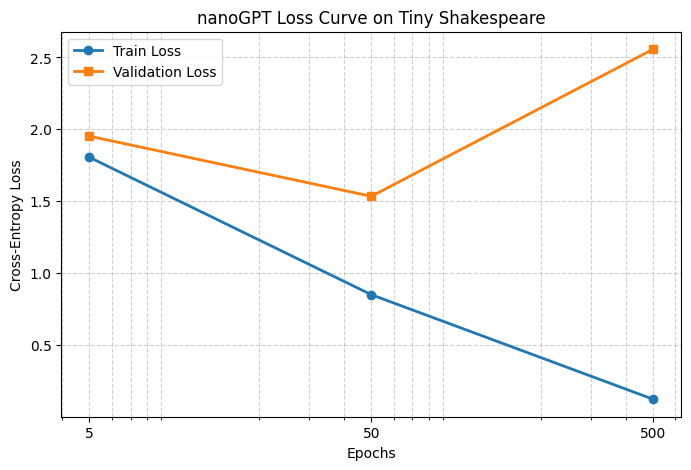

In [ ]:
import matplotlib.pyplot as plt

epochs = [5, 50, 500]
train_loss = [1.8058, 0.8510, 0.1241]
val_loss = [1.9528, 1.5349, 2.5573]

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_loss, label='Train Loss', marker='o', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', marker='s', linewidth=2)

plt.xscale('log')
plt.xticks(epochs, labels=[str(e) for e in epochs]) # Force ticks exactly at 5, 50, 500

plt.title('nanoGPT Loss Curve on Tiny Shakespeare')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.6)

plt.show()

## Part B - Train a PyTorch LSTM baseline

In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F

class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=1):
        super(CharLSTM, self).__init__()
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embed_size)

        # LSTM layer
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)

        # Linear head
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        # x shape: (batch_size, sequence_length)
        embedded = self.embedding(x)

        # out shape: (batch_size, sequence_length, hidden_size)
        out, hidden = self.lstm(embedded, hidden)

        # logits shape: (batch_size, sequence_length, vocab_size)
        logits = self.fc(out)

        return logits, hidden

### Generate Samples

In [ ]:
def generate_text(model, start_char, max_new_tokens, stoi, itos, temperature=0.8):
    model.eval()
    idx = torch.tensor([[stoi[start_char]]], dtype=torch.long).to(device)

    hidden = None
    generated_text = start_char

    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits, hidden = model(idx, hidden)
            # Take the logits for the last character in the sequence
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)

            # Sample from the distribution
            next_idx = torch.multinomial(probs, num_samples=1)

            # Append to our generated text and update input for next step
            generated_text += itos[next_idx.item()]
            idx = next_idx

    return generated_text

### Training Loop

In [ ]:
def get_batch(split):
    # Select the correct dataset
    data = train_data if split == 'train' else val_data

    # Generate random starting indices for our batch
    ix = torch.randint(len(data) - block_size, (batch_size,))

    # Extract the input sequences (x) and target sequences (y)
    x = torch.stack([torch.from_numpy((data[i : i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1 : i+1+block_size]).astype(np.int64)) for i in ix])

    # Move tensors to the GPU
    x, y = x.to(device), y.to(device)
    return x, y

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import os
import pickle

# hyperparams
batch_size = 64
block_size = 256
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Grabbing data
data_dir = 'data/shakespeare_char'
with open(os.path.join(data_dir, 'meta.pkl'), 'rb') as f:
    meta = pickle.load(f)

stoi = meta['stoi']
itos = meta['itos']
vocab_size = meta['vocab_size']

print(f"Vocabulary size loaded: {vocab_size}")

train_data = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
val_data = np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r')

print(f"Train data tokens: {len(train_data)}\n")

# Setup for training

num_train_tokens = len(train_data)

# Calculate steps per epoch
steps_per_epoch = math.floor(num_train_tokens / (batch_size * block_size))

# Define our target checkpoint epochs
checkpoint_epochs = [5, 50, 500]
checkpoint_steps = [epochs * steps_per_epoch for epochs in checkpoint_epochs]
max_iters = checkpoint_steps[-1] + 1

# Initialize model and optimizer
model = CharLSTM(vocab_size, embed_size=384, hidden_size=384, num_layers=1).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# Helper function to estimate loss
@torch.no_grad()
def estimate_loss(eval_iters=100):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, _ = model(X)

            # PyTorch CrossEntropyLoss expects (Batch*Time, Channels)
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            Y = Y.view(B * T)

            loss = nn.functional.cross_entropy(logits, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

# --- Main Training Loop ---
model.train()
for step in range(max_iters):

    # Fetch a batch of data
    X, Y = get_batch('train')

    # Forward pass
    logits, _ = model(X)
    B, T, C = logits.shape
    logits = logits.view(B * T, C)
    Y = Y.view(B * T)

    # Calculate loss
    loss = nn.functional.cross_entropy(logits, Y)

    # Backward pass and optimization
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    # 2. Checkpoint evaluation at ~5, ~50, and ~500 epochs
    if step in checkpoint_steps:
        current_epoch = step // steps_per_epoch
        losses = estimate_loss()
        print(f"Epoch {current_epoch} | Step {step}: Train Loss {losses['train']:.4f}, Val Loss {losses['val']:.4f}")

        # Save the model state
        torch.save(model.state_dict(), f'lstm_epoch_{current_epoch}.pt')

        # Generate the 500-1000 character sample
        sample = generate_text(model, start_char='\n', max_new_tokens=800, stoi=stoi, itos=itos, temperature=0.8)

        # Print Sample
        print(f"Generated Sample for Epoch {current_epoch}:\n{sample}\n")

        # Switch back to training mode after generation
        model.train()

Vocabulary size loaded: 65
Train data tokens: 1003854

Epoch 5 | Step 305: Train Loss 1.5558, Val Loss 1.7036
Generated Sample for Epoch 5:

OM York him the mank marry percourse shall give meet cause your rance of my arsed warrant,
So main link to bear the can me the king it callow all.

COMINIUS:
Hath sweet a willity, kere contance.

MENENIUS:
See uno, let anesel that fiend postand,
And can not call mark to the trune of the light
He is lanness be realoingness done spilting; and the do not being comlan.

DUKE OF YORK:
The perself to the wastant love my never growns,
And, best the die and love knee be duke;
And yet to your biding of they son for your hoon makes mine full,
King her thou do ear the say deate been strange, God, I man now, theqpeation
I an werg not!
Her fortune of my love, and contity
Make on the make to day stay his love.

Clown:
What's say, may sett to Richill much partly.

LADY ELYCHA:
Nom was down, in the will p

Epoch 50 | Step 3050: Train Loss 1.0956, Val Loss 1.5195


### Record Loss

Epoch 5 | Step 305: Train Loss 1.5558, Val Loss 1.7036

Epoch 50 | Step 3050: Train Loss 1.0956, Val Loss 1.5195

Epoch 500 | Step 30500: Train Loss 0.6167, Val Loss 2.5082

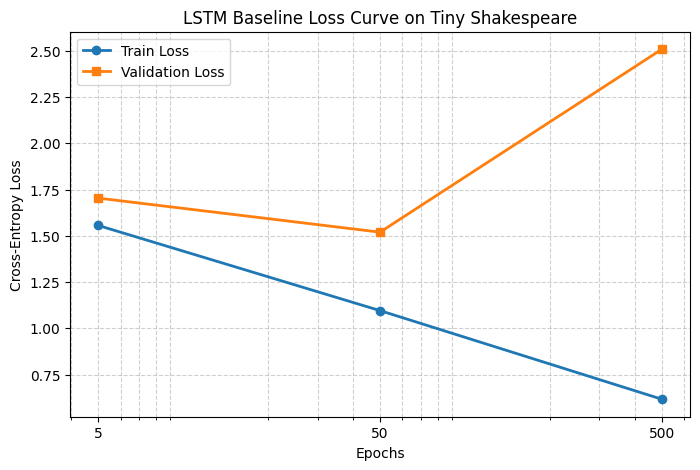

In [ ]:
import matplotlib.pyplot as plt

epochs = [5, 50, 500]
train_loss = [1.5558, 1.0956, 0.6167]
val_loss = [1.7036, 1.5195, 2.5082]

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_loss, label='Train Loss', marker='o', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', marker='s', linewidth=2)

plt.xscale('log')
plt.xticks(epochs, labels=[str(e) for e in epochs]) # Force ticks exactly at 5, 50, 500

plt.title('LSTM Baseline Loss Curve on Tiny Shakespeare')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.6)

plt.show()

## Part C - Comparison Writeup



We will compare GPT vs LSTM at different epochs.

At 5 epochs, we notice that both models output gibberish. Both models format the outputs in typical shakespeare paragraphs however, most of the words are spelled incorrectly. In addition, coherence is low as the words that are correctly spelled does not make sense in the sentences. We notice that a play formatting exists.

At 50 epochs, LSTM's word structure improves. There are few mispelled words and the overall paragraphs start to make sense. However, coherence is still local, sentences don't make sense as a whole. Meanwhile, for the GPT model, we see a consistent play formatting. Word structure resembles Shakespearean vocabulary, however, we lose the plot over different sentences still.

Finally at 500 epochs, LSTM generates mostly real words but the global coherence is still weak. The paragraphs between different people have weak connections. Meanwhile, for GPT, we have excellent formatting and slightly better coherence globally. However, we are likely to see signs of overfitting like repetition in outputs.

The most significant difference between the outputs is the handling of long-range formatting. Since LSTM processes text sequentially, its memory of past characters is compressed into one fixed size hidden state vector. Now when we seek to generate a long sequence, this hidden state can get stuck and produce repetition. It can also struggle to remember a speaker's name from many characters ago. On the other hand, GPT uses self-attention so it is able to look back in context simultaneously. This allows it to maintain the context while continuously generating dialogue, allowing for consistent formatting and less repetition.